## 스케줄러 ONLY 시나리오에서 한 UE의 시간별 AoI 추이

- 실선: UE0의 packet-level AoI 샘플
- 회색 음영: burst source-side `OnOffState` trace로부터 복원한 burst-active 구간
- state trace가 없으면 기존처럼 `traffic_type=0 (BURST)` 수신 시각 기반 추정으로 fallback

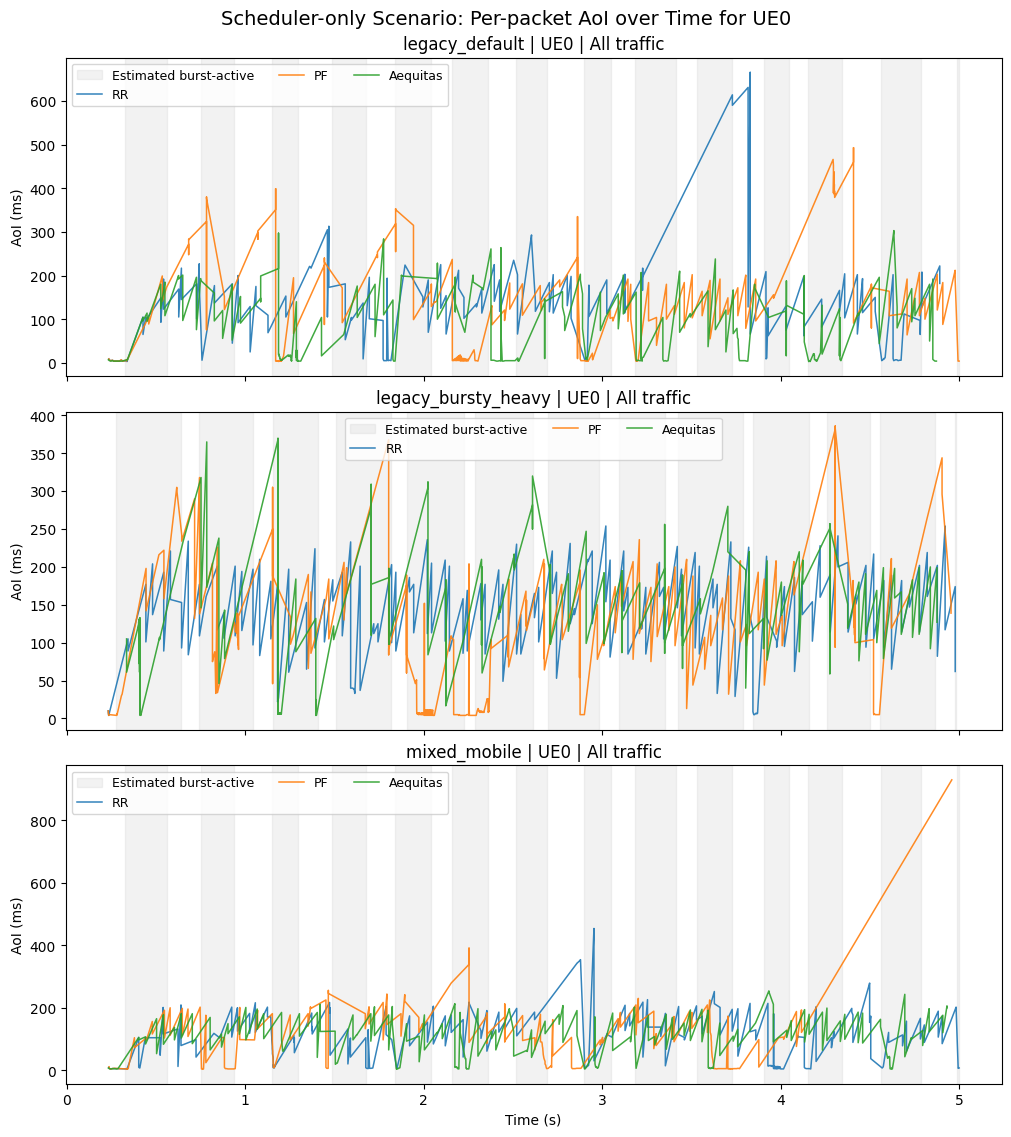

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "grid"])
except ImportError:
    plt.style.use("default")

BASE = Path(".")

scenario_files = {
    "legacy_default": {
        # "RR": BASE / "legacy_default_rr_ue0_aoi.csv",
        "PF": BASE / "legacy_default_pf_ue0_aoi.csv",
        "Aequitas": BASE / "legacy_default_aeq_ue0_aoi.csv",
    },
    "legacy_bursty_heavy": {
        # "RR": BASE / "legacy_bursty_heavy_rr_ue0_aoi.csv",
        "PF": BASE / "legacy_bursty_heavy_pf_ue0_aoi.csv",
        "Aequitas": BASE / "legacy_bursty_heavy_aeq_ue0_aoi.csv",
    },
    "mixed_mobile": {
        # "RR": BASE / "mixed_mobile_rr_ue0_aoi.csv",
        "PF": BASE / "mixed_mobile_pf_ue0_aoi.csv",
        "Aequitas": BASE / "mixed_mobile_aeq_ue0_aoi.csv",
    },
}

scenario_state_files = {
    "legacy_default": {
        # "RR": BASE / "legacy_default_rr_ue0_burst_state.csv",
        "PF": BASE / "legacy_default_pf_ue0_burst_state.csv",
        "Aequitas": BASE / "legacy_default_aeq_ue0_burst_state.csv",
    },
    "legacy_bursty_heavy": {
        # "RR": BASE / "legacy_bursty_heavy_rr_ue0_burst_state.csv",
        "PF": BASE / "legacy_bursty_heavy_pf_ue0_burst_state.csv",
        "Aequitas": BASE / "legacy_bursty_heavy_aeq_ue0_burst_state.csv",
    },
    "mixed_mobile": {
        # "RR": BASE / "mixed_mobile_rr_ue0_burst_state.csv",
        "PF": BASE / "mixed_mobile_pf_ue0_burst_state.csv",
        "Aequitas": BASE / "mixed_mobile_aeq_ue0_burst_state.csv",
    },
}

# 0=BURST, 1=BACKGROUND, None=all
traffic_type = None
burst_gap_threshold_s = 0.20
scenario_time_windows = {
    "mixed_mobile": (2.0, 4.0),
}


def estimate_burst_windows(frames, gap_threshold_s=0.20):
    burst_times = []
    for df in frames:
        t = df.loc[df["traffic_type"] == 0, "time_s"].to_list()
        burst_times.extend(t)

    if not burst_times:
        return []

    burst_times = sorted(set(round(t, 6) for t in burst_times))
    windows = []
    start = burst_times[0]
    prev = burst_times[0]

    for t in burst_times[1:]:
        if t - prev > gap_threshold_s:
            windows.append((start, prev))
            start = t
        prev = t

    windows.append((start, prev))
    return windows


def load_state_windows(state_paths, fallback_frames, gap_threshold_s=0.20):
    state_frames = []
    for path in state_paths:
        if path.exists() and path.stat().st_size > 0:
            df = pd.read_csv(path).sort_values("time_s")
            if not df.empty:
                state_frames.append(df)

    if not state_frames:
        return estimate_burst_windows(fallback_frames, gap_threshold_s=gap_threshold_s)

    event_df = pd.concat(state_frames, ignore_index=True).sort_values("time_s")
    event_df = event_df.drop_duplicates(subset=["time_s", "state"])
    windows = []
    start = None

    for row in event_df.itertuples(index=False):
        if row.state == 1 and start is None:
            start = row.time_s
        elif row.state == 0 and start is not None:
            windows.append((start, row.time_s))
            start = None

    if start is not None:
        end_t = max(df["time_s"].max() for df in fallback_frames if not df.empty)
        windows.append((start, end_t))

    return windows

traffic_label = {None: "All traffic", 0: "BURST only", 1: "BACKGROUND only"}[traffic_type]
colors = {"RR": "#1f77b4", "PF": "#ff7f0e", "Aequitas": "#2ca02c"}

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True, constrained_layout=True)

for ax, (scenario, schedulers) in zip(axes, scenario_files.items()):
    frames = {scheduler: pd.read_csv(path).sort_values("time_s") for scheduler, path in schedulers.items()}
    state_paths = list(scenario_state_files[scenario].values())
    burst_windows = load_state_windows(state_paths, list(frames.values()), gap_threshold_s=burst_gap_threshold_s)
    time_window = scenario_time_windows.get(scenario)

    for idx, (t0, t1) in enumerate(burst_windows):
        if time_window is not None:
            t0 = max(t0, time_window[0])
            t1 = min(t1, time_window[1])
            if t0 >= t1:
                continue
        ax.axvspan(
            t0,
            t1,
            color="0.75",
            alpha=0.20,
            label="Estimated burst-active" if idx == 0 else None,
        )

    for scheduler, path in schedulers.items():
        df = frames[scheduler].copy()
        if traffic_type is not None:
            df = df[df["traffic_type"] == traffic_type].copy()
        if time_window is not None:
            df = df[df["time_s"].between(*time_window)].copy()
        ax.plot(
            df["time_s"],
            df["aoi_ms"],
            label=scheduler,
            color=colors[scheduler],
            linewidth=1.1,
            alpha=0.9,
        )

    if time_window is not None:
        ax.set_xlim(*time_window)
    ax.set_title(f"{scenario} | UE0 | {traffic_label}")
    ax.set_ylabel("AoI (ms)")
    ax.legend(ncol=3, frameon=True, fontsize=9)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Scheduler-only Scenario: Per-packet AoI over Time for UE0", y=1.02, fontsize=14)
plt.show()


## RL/Baseline Metric Boxplots

- UE별 raw metric을 읽어 metric별 boxplot을 그립니다.
- direct baseline은 `summaries/*.txt`, RL은 `evals/*.json`에서 읽습니다.
- 파일이 아직 없는 메커니즘은 자동으로 제외합니다.
- 수치 요약은 `25% / 50% / 75%`만 출력합니다.


Available mechanisms for mixed:
- BWP0-only(PF): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327/mixed/summaries/bwp0_pf.txt
- BWP1-only(PF): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327/mixed/summaries/bwp1_pf.txt
- DRQN(PF): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327_manual/mixed/evals/drqn_long_pf_eval.json
- RQR-DQN(BWP-only): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327_manual/mixed/evals/rqrdqn_long_pf_eval.json
- RQR-DQN(MCS offset): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327_manual/mixed/evals/rqrdqn_full.json
- AEQUITAS(BWP0): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327_manual/mixed/summaries/aequitas_bwp0.txt
- AEQUITAS(BWP1): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327_manual/mixed/summaries/aequitas_bwp1.txt
- DRQN(AEQUITAS): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/

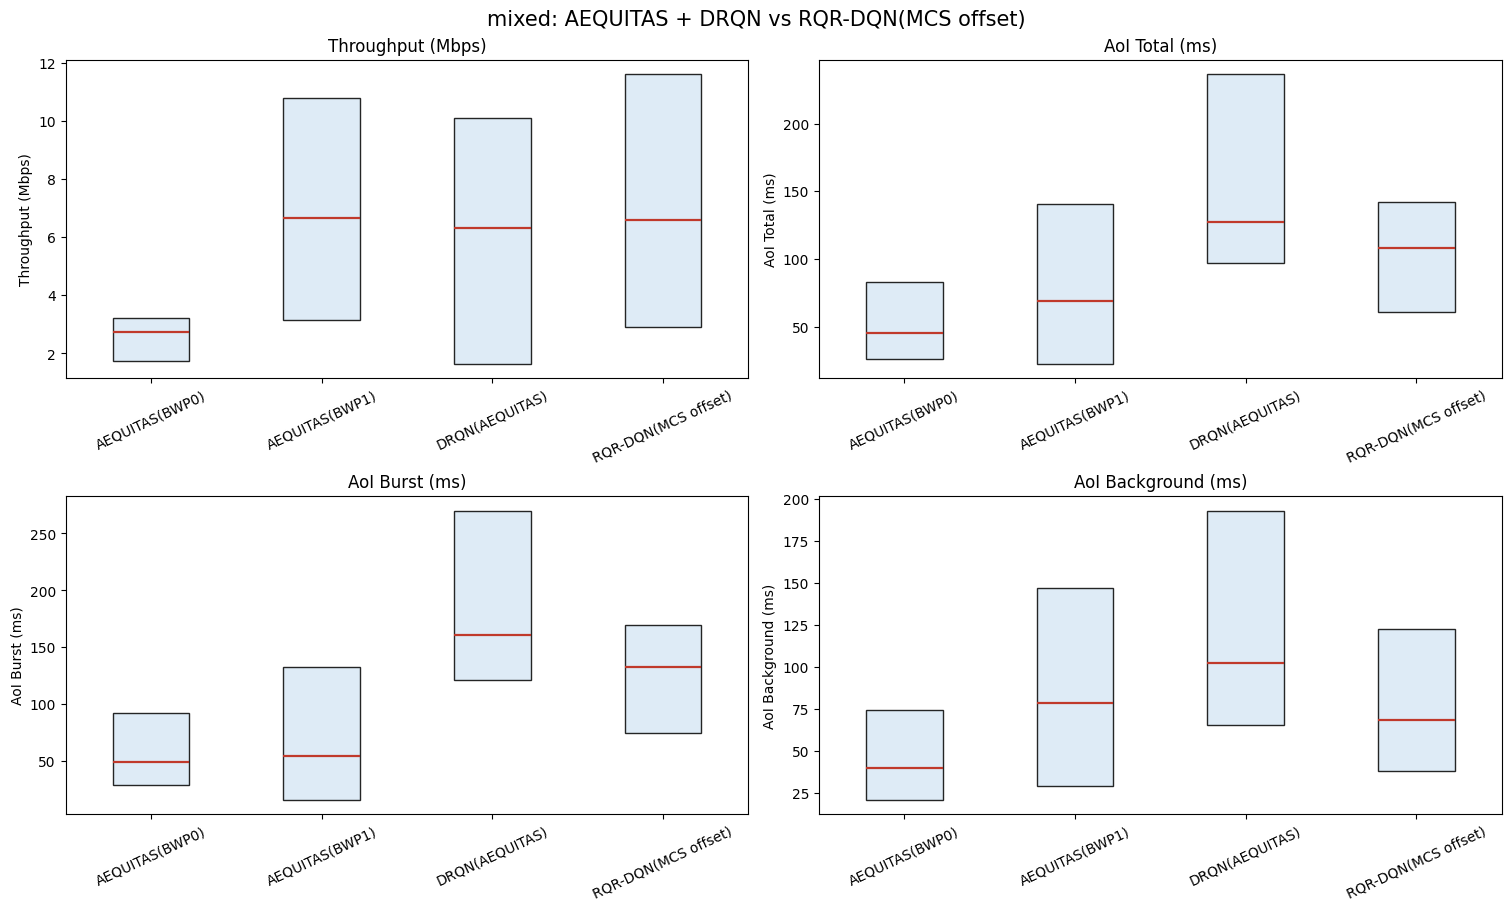


== AEQUITAS + DRQN vs RQR-DQN(MCS offset) ==

[Throughput (Mbps)]
- AEQUITAS(BWP0): Q25=1.745, Q50=2.727, Q75=3.201
- AEQUITAS(BWP1): Q25=3.132, Q50=6.673, Q75=10.773
- DRQN(AEQUITAS): Q25=1.644, Q50=6.320, Q75=10.086
- RQR-DQN(MCS offset): Q25=2.925, Q50=6.599, Q75=11.592

[AoI Total (ms)]
- AEQUITAS(BWP0): Q25=26.287, Q50=45.574, Q75=83.274
- AEQUITAS(BWP1): Q25=22.774, Q50=68.891, Q75=140.674
- DRQN(AEQUITAS): Q25=96.746, Q50=127.667, Q75=236.184
- RQR-DQN(MCS offset): Q25=60.878, Q50=107.959, Q75=142.301

[AoI Burst (ms)]
- AEQUITAS(BWP0): Q25=28.694, Q50=49.573, Q75=92.705
- AEQUITAS(BWP1): Q25=16.014, Q50=54.897, Q75=132.962
- DRQN(AEQUITAS): Q25=121.211, Q50=160.432, Q75=269.998
- RQR-DQN(MCS offset): Q25=74.623, Q50=132.822, Q75=169.407

[AoI Background (ms)]
- AEQUITAS(BWP0): Q25=20.593, Q50=39.643, Q75=74.293
- AEQUITAS(BWP1): Q25=28.812, Q50=78.231, Q75=146.667
- DRQN(AEQUITAS): Q25=65.484, Q50=102.491, Q75=193.072
- RQR-DQN(MCS offset): Q25=38.098, Q50=68.117, Q75=122.364


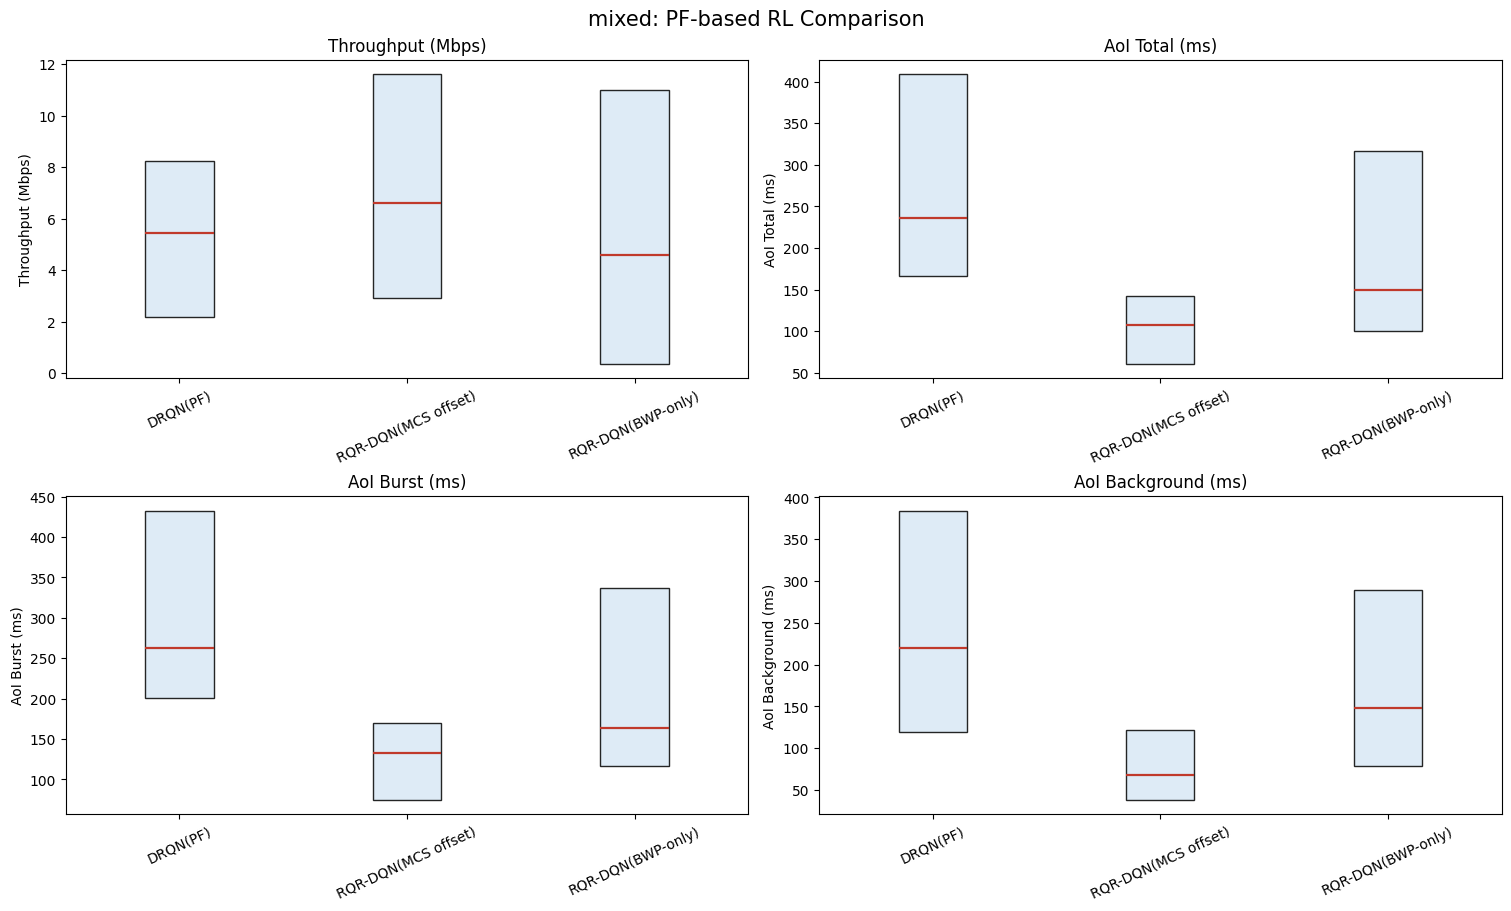


== PF-based RL Comparison ==

[Throughput (Mbps)]
- DRQN(PF): Q25=2.196, Q50=5.424, Q75=8.216
- RQR-DQN(MCS offset): Q25=2.925, Q50=6.599, Q75=11.592
- RQR-DQN(BWP-only): Q25=0.367, Q50=4.606, Q75=11.003

[AoI Total (ms)]
- DRQN(PF): Q25=166.205, Q50=236.246, Q75=408.473
- RQR-DQN(MCS offset): Q25=60.878, Q50=107.959, Q75=142.301
- RQR-DQN(BWP-only): Q25=100.562, Q50=149.824, Q75=316.021

[AoI Burst (ms)]
- DRQN(PF): Q25=200.589, Q50=263.188, Q75=432.662
- RQR-DQN(MCS offset): Q25=74.623, Q50=132.822, Q75=169.407
- RQR-DQN(BWP-only): Q25=116.026, Q50=163.653, Q75=336.420

[AoI Background (ms)]
- DRQN(PF): Q25=119.196, Q50=219.580, Q75=384.284
- RQR-DQN(MCS offset): Q25=38.098, Q50=68.117, Q75=122.364
- RQR-DQN(BWP-only): Q25=78.647, Q50=148.032, Q75=289.451
Available mechanisms for legacy_heavy:
- BWP0-only(PF): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue20_sim10_retrain_20260327/legacy_heavy/summaries/bwp0_pf.txt
- BWP1-only(PF): /home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/ue2

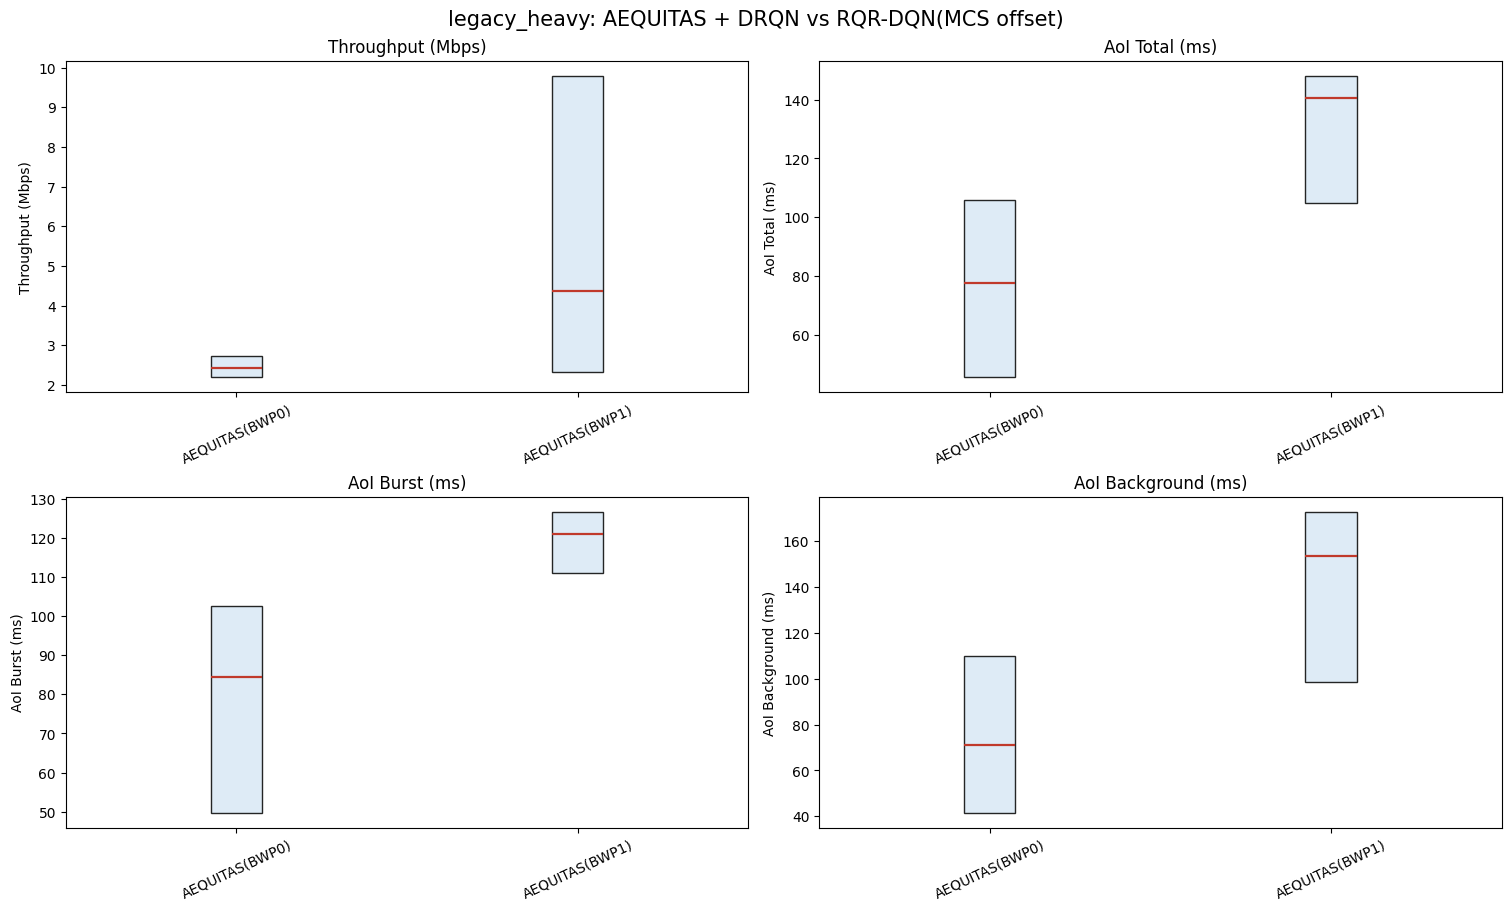


== AEQUITAS + DRQN vs RQR-DQN(MCS offset) ==

[Throughput (Mbps)]
- AEQUITAS(BWP0): Q25=2.195, Q50=2.436, Q75=2.739
- AEQUITAS(BWP1): Q25=2.317, Q50=4.369, Q75=9.787

[AoI Total (ms)]
- AEQUITAS(BWP0): Q25=45.568, Q50=77.754, Q75=105.914
- AEQUITAS(BWP1): Q25=104.784, Q50=140.505, Q75=148.012

[AoI Burst (ms)]
- AEQUITAS(BWP0): Q25=49.692, Q50=84.424, Q75=102.518
- AEQUITAS(BWP1): Q25=111.041, Q50=120.878, Q75=126.689

[AoI Background (ms)]
- AEQUITAS(BWP0): Q25=41.444, Q50=71.083, Q75=109.868
- AEQUITAS(BWP1): Q25=98.515, Q50=153.613, Q75=172.897


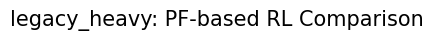


== PF-based RL Comparison ==

[Throughput (Mbps)]

[AoI Total (ms)]

[AoI Burst (ms)]

[AoI Background (ms)]


In [3]:
from pathlib import Path
import json
import re
import numpy as np
import matplotlib.pyplot as plt

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "grid"])
except ImportError:
    plt.style.use("default")

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "aoi_packet_traces" else NOTEBOOK_DIR

RUN_ROOTS = {
    "direct": PROJECT_ROOT / "scratch/rl_bwp/runs/ue20_sim10_retrain_20260327",
    "manual": PROJECT_ROOT / "scratch/rl_bwp/runs/ue20_sim10_retrain_20260327_manual",
}

MECHANISM_SOURCES = {
    "mixed": {
        "BWP0-only(PF)": [("summary", RUN_ROOTS["direct"] / "mixed/summaries/bwp0_pf.txt")],
        "BWP1-only(PF)": [("summary", RUN_ROOTS["direct"] / "mixed/summaries/bwp1_pf.txt")],
        "DRQN(PF)": [("json", RUN_ROOTS["manual"] / "mixed/evals/drqn_long_pf_eval.json")],
        "RQR-DQN(BWP-only)": [("json", RUN_ROOTS["manual"] / "mixed/evals/rqrdqn_long_pf_eval.json")],
        "RQR-DQN(MCS offset)": [("json", RUN_ROOTS["manual"] / "mixed/evals/rqrdqn_full.json")],
        "AEQUITAS(BWP0)": [("summary", RUN_ROOTS["manual"] / "mixed/summaries/aequitas_bwp0.txt")],
        "AEQUITAS(BWP1)": [("summary", RUN_ROOTS["manual"] / "mixed/summaries/aequitas_bwp1.txt")],
        "DRQN(AEQUITAS)": [("json", RUN_ROOTS["manual"] / "mixed/evals/drqn_aeq.json")],
    },
    "legacy_heavy": {
        "BWP0-only(PF)": [("summary", RUN_ROOTS["direct"] / "legacy_heavy/summaries/bwp0_pf.txt")],
        "BWP1-only(PF)": [("summary", RUN_ROOTS["direct"] / "legacy_heavy/summaries/bwp1_pf.txt")],
        "DRQN(PF)": [("json", RUN_ROOTS["manual"] / "legacy_heavy/evals/drqn_long_pf_eval.json")],
        "RQR-DQN(BWP-only)": [("json", RUN_ROOTS["manual"] / "legacy_heavy/evals/rqrdqn_long_pf_eval.json")],
        "RQR-DQN(MCS offset)": [("json", RUN_ROOTS["manual"] / "legacy_heavy/evals/rqrdqn_full.json")],
        "AEQUITAS(BWP0)": [("summary", RUN_ROOTS["manual"] / "legacy_heavy/summaries/aequitas_bwp0.txt")],
        "AEQUITAS(BWP1)": [("summary", RUN_ROOTS["manual"] / "legacy_heavy/summaries/aequitas_bwp1.txt")],
        "DRQN(AEQUITAS)": [("json", RUN_ROOTS["manual"] / "legacy_heavy/evals/drqn_aeq.json")],
    },
}

COMPARISON_GROUPS = [
    {
        "title": "AEQUITAS + DRQN vs RQR-DQN(MCS offset)",
        "mechanisms": ["AEQUITAS(BWP0)", "AEQUITAS(BWP1)", "DRQN(AEQUITAS)", "RQR-DQN(MCS offset)"],
    },
    {
        "title": "PF-based RL Comparison",
        "mechanisms": ["DRQN(PF)", "RQR-DQN(MCS offset)", "RQR-DQN(BWP-only)"],
    },
]

METRICS = [
    ("thr_mbps", "Throughput (Mbps)"),
    ("aoi_ms", "AoI Total (ms)"),
    ("aoi_burst_ms", "AoI Burst (ms)"),
    ("aoi_bg_ms", "AoI Background (ms)"),
]

SUMMARY_PATTERN = re.compile(r"ue=(\d+),thrMbps=([^,]+),aoiBurstMs=([^,]+),aoiBgMs=([^,]+)")


def parse_summary_txt(path: Path):
    metrics = {"thr_mbps": [], "aoi_burst_ms": [], "aoi_bg_ms": [], "aoi_ms": []}
    for line in path.read_text().splitlines():
        match = SUMMARY_PATTERN.match(line.strip())
        if not match:
            continue
        thr = float(match.group(2))
        aoi_burst = float(match.group(3))
        aoi_bg = float(match.group(4))
        metrics["thr_mbps"].append(thr)
        metrics["aoi_burst_ms"].append(aoi_burst)
        metrics["aoi_bg_ms"].append(aoi_bg)
        metrics["aoi_ms"].append(0.5 * (aoi_burst + aoi_bg))
    return metrics


def parse_eval_json(path: Path):
    data = json.loads(path.read_text())
    means = data.get("episode_metric_means", {})
    metrics = {"thr_mbps": [], "aoi_burst_ms": [], "aoi_bg_ms": [], "aoi_ms": []}
    for key, value in means.items():
        if not isinstance(value, dict) or "mean" not in value:
            continue
        metric_mean = value["mean"]
        if re.match(r"ue\d+_thr_mbps$", key):
            metrics["thr_mbps"].append(metric_mean)
        elif re.match(r"ue\d+_aoi_burst_ms$", key):
            metrics["aoi_burst_ms"].append(metric_mean)
        elif re.match(r"ue\d+_aoi_bg_ms$", key):
            metrics["aoi_bg_ms"].append(metric_mean)
        elif re.match(r"ue\d+_aoi_ms$", key):
            metrics["aoi_ms"].append(metric_mean)
    return metrics


def load_first_available(candidates):
    for kind, path in candidates:
        if path.exists():
            if kind == "summary":
                return path, parse_summary_txt(path)
            if kind == "json":
                return path, parse_eval_json(path)
    return None, None


def collect_scenario_metrics(scenario_name):
    loaded = {}
    for mechanism, candidates in MECHANISM_SOURCES[scenario_name].items():
        path, metrics = load_first_available(candidates)
        if metrics is not None:
            loaded[mechanism] = {"path": path, "metrics": metrics}
    return loaded


def quartile_triplet(values):
    arr = np.asarray(values, dtype=float)
    return {
        "q25": float(np.percentile(arr, 25)),
        "q50": float(np.percentile(arr, 50)),
        "q75": float(np.percentile(arr, 75)),
    }


def draw_group_boxplots(scenario_name, loaded, group):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    axes = axes.flatten()

    for ax, (metric_key, metric_label) in zip(axes, METRICS):
        labels = []
        series = []
        for mechanism in group["mechanisms"]:
            payload = loaded.get(mechanism)
            if payload is None:
                continue
            values = payload["metrics"].get(metric_key, [])
            if values:
                labels.append(mechanism)
                series.append(values)

        if not series:
            ax.set_visible(False)
            continue

        stats = []
        for label, values in zip(labels, series):
            q = quartile_triplet(values)
            stats.append({
                "label": label,
                "med": q["q50"],
                "q1": q["q25"],
                "q3": q["q75"],
                "whislo": q["q25"],
                "whishi": q["q75"],
                "fliers": [],
            })

        bp = ax.bxp(stats, patch_artist=True, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor("#d9e8f5")
            patch.set_alpha(0.85)
        for median in bp["medians"]:
            median.set_color("#c0392b")
            median.set_linewidth(1.6)
        for whisker in bp["whiskers"]:
            whisker.set_alpha(0.0)
        for cap in bp["caps"]:
            cap.set_alpha(0.0)

        ax.set_title(metric_label)
        ax.tick_params(axis="x", rotation=25)
        ax.set_ylabel(metric_label)

    fig.suptitle(f"{scenario_name}: {group['title']}", fontsize=15)
    plt.show()


def print_group_summary(group, loaded):
    print(f"\n== {group['title']} ==")
    for metric_key, metric_label in METRICS:
        print(f"\n[{metric_label}]")
        for mechanism in group["mechanisms"]:
            payload = loaded.get(mechanism)
            if payload is None:
                continue
            values = payload["metrics"].get(metric_key, [])
            if not values:
                continue
            q = quartile_triplet(values)
            print(f"- {mechanism}: Q25={q['q25']:.3f}, Q50={q['q50']:.3f}, Q75={q['q75']:.3f}")


for scenario_name in ["mixed", "legacy_heavy"]:
    loaded = collect_scenario_metrics(scenario_name)
    if not loaded:
        print(f"No available files for {scenario_name}")
        continue

    print(f"Available mechanisms for {scenario_name}:")
    for mechanism, payload in loaded.items():
        print(f"- {mechanism}: {payload['path']}")

    print(f"\nQuartile summary for {scenario_name} (Q25 / Q50 / Q75)")
    for group in COMPARISON_GROUPS:
        draw_group_boxplots(scenario_name, loaded, group)
        print_group_summary(group, loaded)




## TEMP

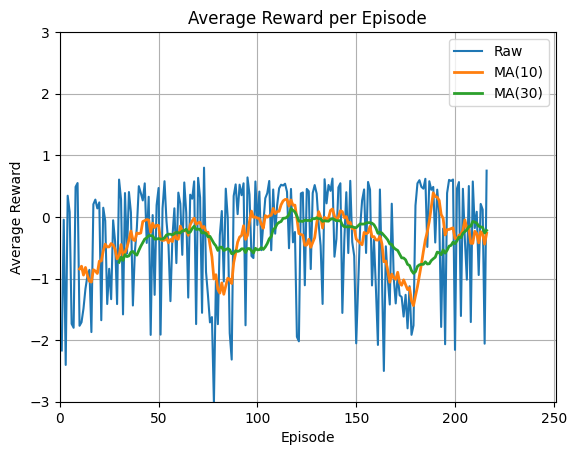

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv("a.csv")

# episode별 평균 reward 계산
episode_avg = df.groupby("episode")["avg_reward"].mean().reset_index()

# 이동평균 (window=10)
episode_avg["ma10"] = episode_avg["avg_reward"].rolling(window=10).mean()
episode_avg["ma30"] = episode_avg["avg_reward"].rolling(window=30).mean()
# episode_avg["ma50"] = episode_avg["avg_reward"].rolling(window=50).mean()

# 시각화
plt.figure()

# 원래 값
plt.plot(episode_avg["episode"], episode_avg["avg_reward"], label="Raw")

# 이동평균
plt.plot(episode_avg["episode"], episode_avg["ma10"], label="MA(10)", linewidth=2)
plt.plot(episode_avg["episode"], episode_avg["ma30"], label="MA(30)", linewidth=2)
# plt.plot(episode_avg["episode"], episode_avg["ma50"], label="MA(50)", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Average Reward per Episode")
plt.xlim(0, 251)
plt.ylim(-3, 3)
plt.yticks(range(-3, 4, 1))
plt.grid()
plt.legend()

plt.show()

In [92]:
from pathlib import Path
import json
import re
import matplotlib.pyplot as plt

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "grid"])
except ImportError:
    plt.style.use("default")

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1] if NOTEBOOK_DIR.name == "aoi_packet_traces" else NOTEBOOK_DIR

BASE = PROJECT_ROOT / "scratch/rl_bwp/runs/appmix_graph_data_priority_20260401_ue20_sim2_eval5_ep500_step001_opt/appmix/eval_ep0200_seedavg_sim2"

MECHANISMS = [
    ("BWP0+Aequitas", BASE / "bwp0_aeq_seedavg.json"),
    ("RQR-DQN+PF", BASE / "rqrdqn_pf_seedavg.json"),
    ("BWP1+Aequitas", BASE / "bwp1_aeq_seedavg.json"),
    ("DRQN+Aequitas", BASE / "drqn_aeq_seedavg.json"),
]


def load_baseline_seed_samples(seed_json_path, metric_name):
    data = json.loads(seed_json_path.read_text(encoding="utf-8"))
    summary_path = Path(data["summary_file"])
    text = summary_path.read_text(encoding="utf-8")
    if metric_name == "thr_mbps":
        pattern = re.compile(r"thrMbps=([0-9.]+)")
    elif metric_name == "aoi_ms":
        pattern = re.compile(r"aoiNodeMs=([0-9.]+)")
    else:
        raise ValueError(metric_name)
    values = []
    for line in text.splitlines():
        if not line.startswith("ue="):
            continue
        m = pattern.search(line)
        if m:
            values.append(float(m.group(1)))
    return values


def load_rl_seed_samples(seed_json_path, metric_name):
    data = json.loads(seed_json_path.read_text(encoding="utf-8"))
    metric_block = data.get("episode_metric_last") or data.get("episode_metric_means")
    if metric_block is None:
        raise KeyError(f"No UE metric block in {seed_json_path}")
    suffix = "thr_mbps" if metric_name == "thr_mbps" else "aoi_ms"
    values = []
    for ue_idx in range(20):
        key = f"ue{ue_idx}_{suffix}"
        if key in metric_block:
            raw = metric_block[key]
            value = raw.get("mean") if isinstance(raw, dict) else raw
            values.append(float(value))
    if not values:
        raise KeyError(f"No UE samples for {metric_name} in {seed_json_path}")
    return values


def load_seedavg_samples(seedavg_json_path, metric_name):
    data = json.loads(seedavg_json_path.read_text(encoding="utf-8"))
    source_files = [Path(x) for x in data["source_files"]]
    values = []
    for src in source_files:
        if src.name.startswith("bwp"):
            values.extend(load_baseline_seed_samples(src, metric_name))
        else:
            values.extend(load_rl_seed_samples(src, metric_name))
    return values


labels = []
thr_data = []
aoi_data = []
for label, path in MECHANISMS:
    labels.append(label)
    thr_data.append(load_seedavg_samples(path, "thr_mbps"))
    aoi_data.append(load_seedavg_samples(path, "aoi_ms"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

thr_bp = axes[0].boxplot(thr_data, labels=labels, patch_artist=True, showfliers=False)
aoi_bp = axes[1].boxplot(aoi_data, labels=labels, patch_artist=True, showfliers=False)

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]
for bp in (thr_bp, aoi_bp):
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.4)

axes[0].set_title("Throughput Distribution Across 3 Seeds")
axes[0].set_ylabel("Throughput (Mbps)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].set_title("AoI Distribution Across 3 Seeds")
axes[1].set_ylabel("AoI (ms)")
axes[1].tick_params(axis="x", rotation=15)

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/jshyeon/ns-3.46-bwp/scratch/rl_bwp/runs/appmix_graph_data_priority_20260401_ue20_sim2_eval5_ep500_step001_opt/appmix/eval_ep0200_seedavg_sim2/bwp0_aeq_seedavg.json'

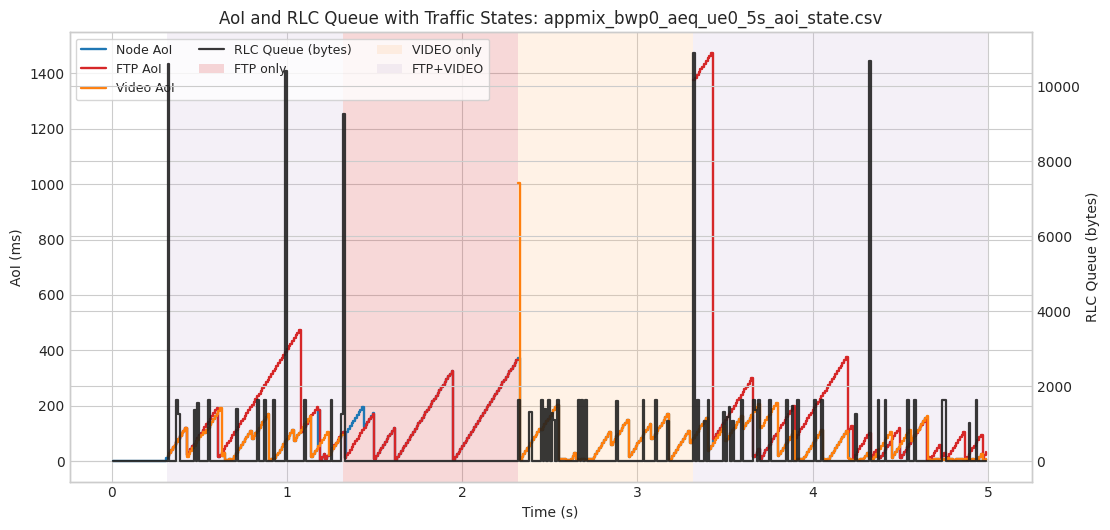

In [610]:
# AoI time-series for narrow BWP + Aequitas
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "grid"])
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")

base_dir = Path('./BWP1+Aequitas')
state_trace_candidates = sorted(base_dir.glob('appmix_bwp0_aeq_ue0_*_aoi_state.csv'))

run_bases = []
for state_path in state_trace_candidates:
    base = state_path.name.removesuffix('_aoi_state.csv')
    queue_path = base_dir / f'{base}_queue.csv'
    app_state_path_candidate = base_dir / f'{base}_app_state.csv'
    if queue_path.exists() and app_state_path_candidate.exists():
        run_bases.append(base)

selected_base = run_bases[-1] if run_bases else None
state_trace_path = (base_dir / f'{selected_base}_aoi_state.csv') if selected_base else None
queue_trace_path = (base_dir / f'{selected_base}_queue.csv') if selected_base else None
app_state_path = (base_dir / f'{selected_base}_app_state.csv') if selected_base else None

if state_trace_path is None:
    raise FileNotFoundError("AoI state trace CSV를 찾지 못했습니다.")
if queue_trace_path is None:
    raise FileNotFoundError("Queue trace CSV를 찾지 못했습니다.")
if app_state_path is None:
    raise FileNotFoundError("App state trace CSV를 찾지 못했습니다.")

df = pd.read_csv(state_trace_path).sort_values("time_s").reset_index(drop=True)
queue_df = pd.read_csv(queue_trace_path).sort_values("time_s").reset_index(drop=True)
app_df = pd.read_csv(app_state_path).sort_values("start_s").reset_index(drop=True)

def active_mask(df, app_df, col):
    if col == 'aoi_ftp_ms':
        on_col = 'ftp_on'
    elif col == 'aoi_video_ms':
        on_col = 'video_on'
    else:
        return pd.Series(True, index=df.index)
    mask = pd.Series(False, index=df.index)
    for row in app_df.itertuples(index=False):
        if getattr(row, on_col, 0):
            mask |= (df['time_s'] >= row.start_s) & (df['time_s'] < row.end_s)
    return mask

# display(df.head())
# display(queue_df.head())
# display(app_df)

columns_to_plot = ["aoi_node_ms", "aoi_ftp_ms", "aoi_video_ms"]
labels = {
    "aoi_node_ms": "Node AoI",
    "aoi_ftp_ms": "FTP AoI",
    "aoi_gaming_ms": "Gaming AoI",
    "aoi_video_ms": "Video AoI",
}
colors = {
    "aoi_node_ms": "#1f77b4",
    "aoi_ftp_ms": "#d62728",
    "aoi_gaming_ms": "#2ca02c",
    "aoi_video_ms": "#ff7f0e",
}
state_colors = {
    "ftp_only": "#d62728",
    "video_only": "#ffbb78",
    "ftp_video": "#c5b0d5",
}

fig, ax = plt.subplots(figsize=(11.2, 5.4))
for row in app_df.itertuples(index=False):
    color = state_colors.get(row.state_label, "#dddddd")
    ax.axvspan(row.start_s, row.end_s, color=color, alpha=0.18, lw=0)

line_handles = []
for col in columns_to_plot:
    if col in df.columns:
        plot_series = df[col].where(active_mask(df, app_df, col))
        ln, = ax.step(df["time_s"], plot_series, where="post", linewidth=1.7, label=labels.get(col, col), color=colors.get(col))
        line_handles.append(ln)

ax2 = ax.twinx()
queue_handle = None
queue_col = None
if "total_rlc_queue_bytes" in queue_df.columns:
    queue_col = "total_rlc_queue_bytes"
elif "queue_bytes" in df.columns:
    queue_col = "queue_bytes"

if queue_col == "total_rlc_queue_bytes":
    queue_handle, = ax2.step(queue_df["time_s"], queue_df[queue_col], where="post", linewidth=1.6, color="#222222", alpha=0.9, label="RLC Queue (bytes)")
    ax2.set_ylabel("RLC Queue (bytes)")
elif queue_col == "queue_bytes":
    queue_handle, = ax2.step(df["time_s"], df[queue_col], where="post", linewidth=1.6, color="#222222", alpha=0.9, label="RLC Queue (bytes)")
    ax2.set_ylabel("RLC Queue (bytes)")

traffic_handles = [
    Patch(facecolor=state_colors["ftp_only"], alpha=0.18, label="FTP only"),
    Patch(facecolor=state_colors["video_only"], alpha=0.18, label="VIDEO only"),
    Patch(facecolor=state_colors["ftp_video"], alpha=0.18, label="FTP+VIDEO"),
]
legend_handles = list(line_handles)
legend_labels = [h.get_label() for h in line_handles]
if queue_handle is not None:
    legend_handles.append(queue_handle)
    legend_labels.append(queue_handle.get_label())
legend_handles += traffic_handles
legend_labels += [h.get_label() for h in traffic_handles]
ax.legend(legend_handles, legend_labels, frameon=True, fontsize=9, ncol=3, loc="upper left")
ax.set_title(f"AoI and RLC Queue with Traffic States: {state_trace_path.name}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("AoI (ms)")
plt.tight_layout()
plt.show()
